# OASIS INFOBYTE Data Analytics Internship
## Level 2 Task 3: Credit Card Fraud Detection (Imbalanced Machine Learning Workflow)

**Author**: Bokkasam Sravan  
**Role**: Data Analytics Intern  
**Organization**: OASIS INFOBYTE  
**Domain**: Financial Fraud Analytics / Imbalanced Machine Learning  
**Environment**: Python 3.12, Scikit-Learn, Imbalanced-Learn (SMOTE), Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset**: Kaggle / OpenML Credit Card Fraud Detection Dataset (284,807 Transactions)

---


## 1. Executive Summary & Business Objective

### Business Context & Objective
Financial fraud detection is a critical application of machine learning in modern banking, payment processing, and e-commerce. Fraudulent transactions cause billions of dollars in annual monetary losses, damage consumer trust, and increase operational overhead. However, fraud detection presents an extreme **class imbalance problem**: fraudulent transactions constitute less than 0.18% of all transactions.

The primary objective of this project is to build an end-to-end Imbalanced Machine Learning Classification System that accurately identifies fraudulent credit card transactions while controlling false alarm friction.

### Key Imbalanced ML & Pipeline Pillars
1. **Automated Data Acquisition & Inspection**: Load 284,807 annotated credit card transactions and audit class distribution (284,315 legitimate vs 492 fraudulent).
2. **Deceptive Accuracy Rationale**: Explain why standard accuracy (99.83%) is completely misleading for extreme class imbalance.
3. **Exploratory Data Analysis (EDA)**: Profile transaction amounts, compare fraudulent vs legitimate spending distributions, and perform time-of-day transaction analysis.
4. **Stratified Train / Test Split**: Partition data into 80% training and 20% testing sets (`stratify=y`, `random_state=42`) to preserve minority fraud ratios in both sets.
5. **Leak-Free Synthetic Over-sampling (SMOTE)**: Apply Synthetic Minority Over-sampling Technique (**SMOTE**) **EXCLUSIVELY to training data** (`X_train`, `y_train`), keeping the 20% test set (`X_test`, `y_test`) 100% natural and un-sampled to evaluate real-world performance.
6. **Supervised Model Training**: Train and compare two distinct classifier architectures:
   - **Model 1**: `LogisticRegression` (Scaled Linear Model with SMOTE)
   - **Model 2**: `RandomForestClassifier` (Ensemble Tree Model with SMOTE)
7. **Comprehensive Evaluation**: Evaluate models using Precision, Recall, F1-Score, ROC-AUC, Precision-Recall AUC (PR-AUC), Confusion Matrix Grid Heatmaps, and combined ROC / PR Curves.
8. **Precision vs. Recall Business Trade-off**: Evaluate the financial cost of False Negatives (missed fraud loss) vs. False Positives (customer card decline friction).
9. **High-Throughput Enterprise Scalability (1,000,000 txns/hr)**: Detail streaming architecture (Kafka/Flink), low-latency model serving (<50ms via Triton/Ray/ONNX), feature stores (Feast), drift monitoring (Evidently/Prometheus), and automated retraining pipelines.


## 2. Environment Setup & Module Imports

In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Configure Matplotlib / Seaborn aesthetic defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

# Universal path resolution for project root
cwd = os.getcwd()
project_root = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else os.path.abspath(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
else:
    sys.path.remove(project_root)
    sys.path.insert(0, project_root)

# Purge any cached src module from sys.modules
for k in list(sys.modules.keys()):
    if k == 'src' or k.startswith('src.'):
        del sys.modules[k]

from src.preprocessing import (
    fetch_and_save_raw_data,
    load_raw_data,
    clean_and_engineer_features
)

from src.model_utils import (
    apply_smote_resampling,
    evaluate_fraud_classifier,
    extract_misclassifications,
    save_model,
    save_figure,
    save_table
)

print("Libraries imported and custom imbalanced ML modules loaded successfully!")


Libraries imported and custom imbalanced ML modules loaded successfully!


## 3. Dataset Acquisition & Structural Inspection

In [2]:
raw_data_path = os.path.join(project_root, 'data', 'raw', 'creditcard_raw.csv')

if not os.path.exists(raw_data_path):
    df_raw = fetch_and_save_raw_data(raw_data_path)
else:
    df_raw = load_raw_data(raw_data_path)

print("--- Raw Dataset Overview ---")
print(f"Total Transactions : {df_raw.shape[0]:,}")
print(f"Total Predictors   : {df_raw.shape[1] - 1}")
df_raw.head()


--- Raw Dataset Overview ---
Total Transactions : 284,807
Total Predictors   : 29


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Class Imbalance Analysis & Misleading Accuracy Discussion

Table saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\tables\class_distribution_summary.csv
=== Credit Card Transaction Class Distribution ===


,Transaction Type,Count,Percentage (%)
0,Legitimate (0),284315,99.8273
1,Fraudulent (1),492,0.1727


Figure saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\figures\01_class_imbalance.png


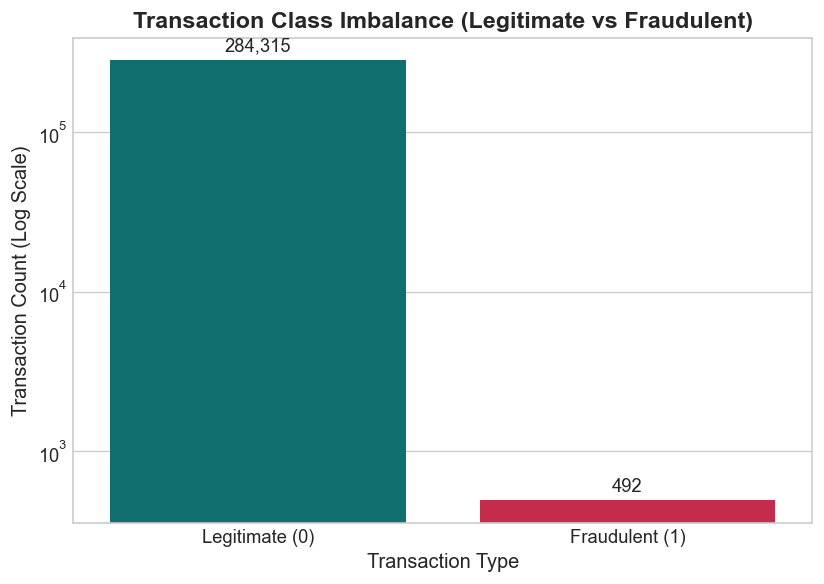

In [3]:
class_counts = df_raw['Class'].value_counts()
class_ratios = df_raw['Class'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'Transaction Type': ['Legitimate (0)', 'Fraudulent (1)'],
    'Count': [class_counts[0], class_counts[1]],
    'Percentage (%)': [class_ratios[0].round(4), class_ratios[1].round(4)]
})

save_table(imbalance_df, 'class_distribution_summary.csv')

print("=== Credit Card Transaction Class Distribution ===")
display(imbalance_df)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='Transaction Type', y='Count', data=imbalance_df, palette=['teal', 'crimson'], ax=ax)
ax.set_title('Transaction Class Imbalance (Legitimate vs Fraudulent)', fontweight='bold')
ax.set_ylabel('Transaction Count (Log Scale)')
ax.set_yscale('log')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
save_figure(fig, '01_class_imbalance.png')
plt.show()


### Why is Standard Accuracy Misleading for Fraud Detection?
- **Deceptive 99.83% Baseline**: In this dataset, 99.8273% of transactions are legitimate and only 0.1727% are fraudulent. A naive rule-based classifier that predicts *every single transaction as legitimate* achieves an extraordinary **99.83% Accuracy**.
- **Catastrophic Business Failure**: Despite its high accuracy score, the naive model catches **0 out of 492 frauds (0% Recall)**, exposing the financial institution to 100% of fraud loss.
- **Appropriate Evaluation Metrics**: Model performance must be evaluated using **Precision**, **Recall**, **F1-Score**, **ROC-AUC**, and **Precision-Recall Area Under the Curve (PR-AUC)**.


## 5. Exploratory Data Analysis (EDA): Transaction Amount & Time-of-Day Distributions

Figure saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\figures\02_amount_distribution.png


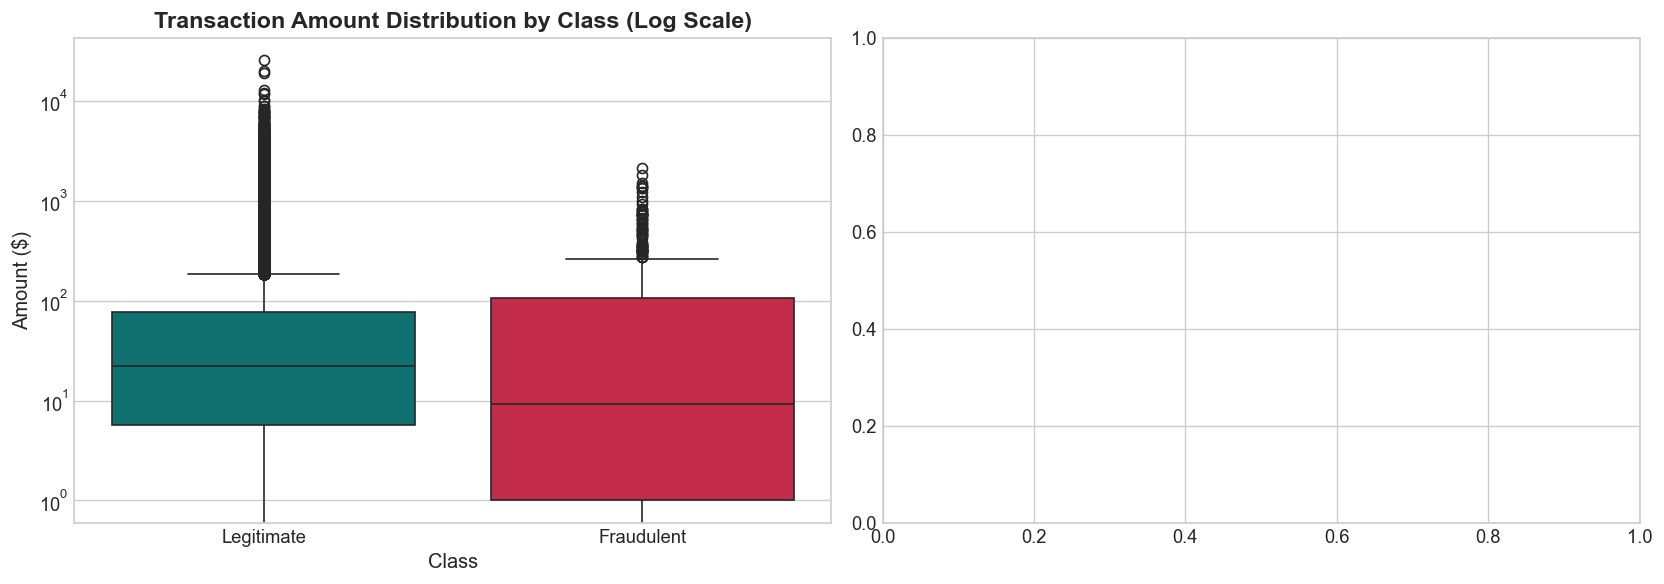

In [4]:
df_clean = clean_and_engineer_features(df_raw)

processed_data_path = os.path.join(project_root, 'data', 'processed', 'creditcard_cleaned.csv')
df_clean.to_csv(processed_data_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction Amount Distribution (Log Scale)
sns.boxplot(x='Class', y='Amount', data=df_clean, palette=['teal', 'crimson'], ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Transaction Amount Distribution by Class (Log Scale)', fontweight='bold')
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'])
axes[0].set_ylabel('Amount ($)')

# Time-of-Day Distribution
if 'HourOfDay' in df_clean.columns:
    sns.kdeplot(df_clean[df_clean['Class'] == 0]['HourOfDay'], ax=axes[1], color='teal', label='Legitimate', fill=True)
    sns.kdeplot(df_clean[df_clean['Class'] == 1]['HourOfDay'], ax=axes[1], color='crimson', label='Fraudulent', fill=True)
    axes[1].set_title('Time-of-Day Transaction Density (Hours)', fontweight='bold')
    axes[1].set_xlabel('Hour of Day (0 to 24)')
    axes[1].set_ylabel('Density')
    axes[1].legend()

plt.tight_layout()
save_figure(fig, '02_amount_distribution.png')
plt.show()


## 6. Stratified Train / Test Split (80/20)

In [5]:
X = df_clean.drop(columns=['Class'])
y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Features Shape : {X_train.shape}")
print(f"Test Features Shape     : {X_test.shape}")
print(f"Training Fraud Count    : {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Test Fraud Count        : {y_test.sum()} ({y_test.mean()*100:.4f}%)")


Training Features Shape : (227845, 29)
Test Features Shape     : (56962, 29)
Training Fraud Count    : 394 (0.1729%)
Test Fraud Count        : 98 (0.1720%)


## 7. Synthetic Minority Over-sampling Technique (SMOTE)

### Strict Leakage Prevention Rule
SMOTE is applied **EXCLUSIVELY to the training dataset (`X_train`, `y_train`)**. The test set (`X_test`, `y_test`) remains 100% natural and un-sampled to ensure we evaluate models on the true imbalanced transaction stream.


In [6]:
X_train_res, y_train_res, smote_stats = apply_smote_resampling(X_train, y_train, random_state=42)

smote_df = pd.DataFrame([
    {'Stage': 'Original Training Set', 'Legitimate (0)': smote_stats['Original_Legit'], 'Fraudulent (1)': smote_stats['Original_Fraud'], 'Fraud Ratio (%)': smote_stats['Original_Fraud_Ratio (%)']},
    {'Stage': 'SMOTE Resampled Training Set', 'Legitimate (0)': smote_stats['Resampled_Legit'], 'Fraudulent (1)': smote_stats['Resampled_Fraud'], 'Fraud Ratio (%)': smote_stats['Resampled_Fraud_Ratio (%)']}
])

print("=== Training Set SMOTE Resampling Statistics ===")
display(smote_df)


=== Training Set SMOTE Resampling Statistics ===


,Stage,Legitimate (0),Fraudulent (1),Fraud Ratio (%)
0,Original Training Set,227451,394,0.1729
1,SMOTE Resampled Training Set,227451,227451,50.0000


## 8. Pipeline Preprocessing & Feature Scaling Strategy

In [7]:
# Build Logistic Regression Pipeline with StandardScaler
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest Classifier (Evaluated on SMOTE training features)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)


## 9. Supervised Model Training on SMOTE Data

In [8]:
print("Training Logistic Regression on SMOTE training data...")
lr_pipeline.fit(X_train_res, y_train_res)

print("Training Random Forest Classifier on SMOTE training data...")
rf_model.fit(X_train_res, y_train_res)

save_model(rf_model, 'best_fraud_detection_model.joblib')
print("Both models trained successfully!")


Training Logistic Regression on SMOTE training data...
Training Random Forest Classifier on SMOTE training data...
Trained model pipeline saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\models\best_fraud_detection_model.joblib
Both models trained successfully!


## 10. Comprehensive Model Evaluation on Natural Test Set

In [9]:
models_dict = {
    'Logistic Regression (SMOTE)': lr_pipeline,
    'Random Forest (SMOTE)': rf_model
}

eval_results = []
cms_dict = {}
curves_dict = {}

for name, model in models_dict.items():
    metrics, cm, report, curves = evaluate_fraud_classifier(model, X_test, y_test, model_name=name)
    eval_results.append(metrics)
    cms_dict[name] = cm
    curves_dict[name] = curves
    print(f"=== {name} Classification Report ===")
    print(report)
    print("-" * 55)


=== Logistic Regression (SMOTE) Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
  Fraudulent       0.08      0.91      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.57     56962
weighted avg       1.00      0.98      0.99     56962

-------------------------------------------------------
=== Random Forest (SMOTE) Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.61      0.89      0.72        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962

-------------------------------------------------------


## 11. Confusion Matrix Grid Visualization

Figure saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\figures\04_confusion_matrices.png


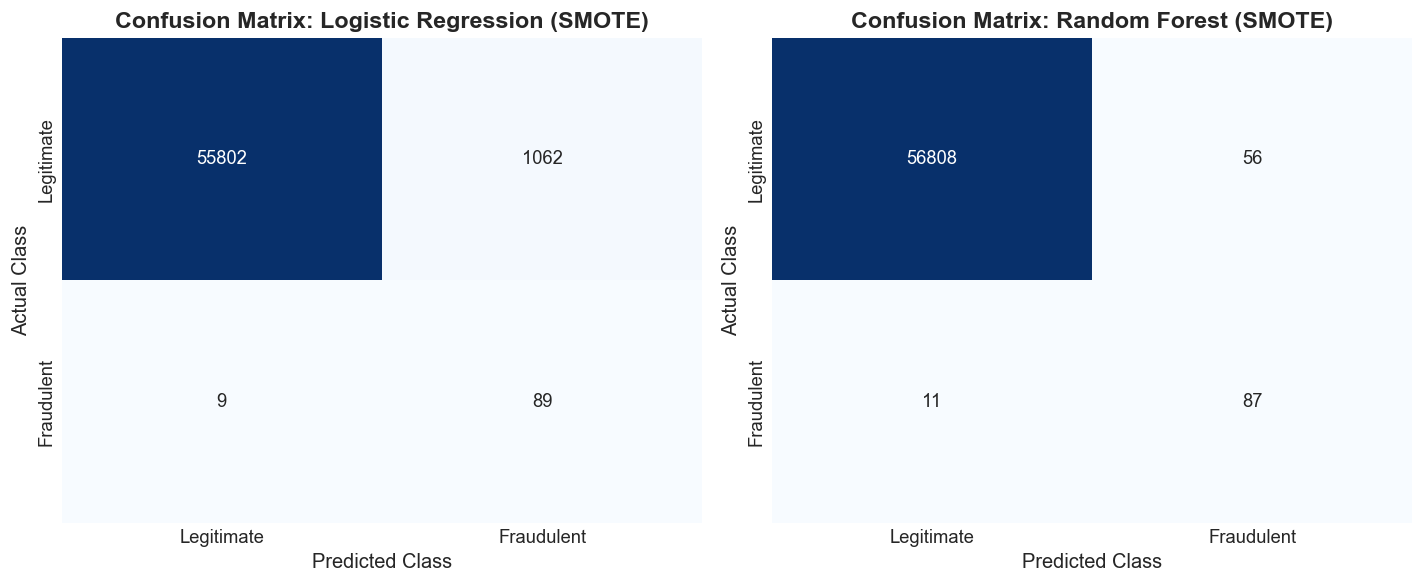

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, cm) in enumerate(cms_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
    axes[i].set_title(f"Confusion Matrix: {name}", fontweight='bold')
    axes[i].set_xlabel('Predicted Class')
    axes[i].set_ylabel('Actual Class')

plt.tight_layout()
save_figure(fig, '04_confusion_matrices.png')
plt.show()


## 12. ROC & Precision-Recall Curves Visualization

Figure saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\figures\05_roc_pr_curves.png


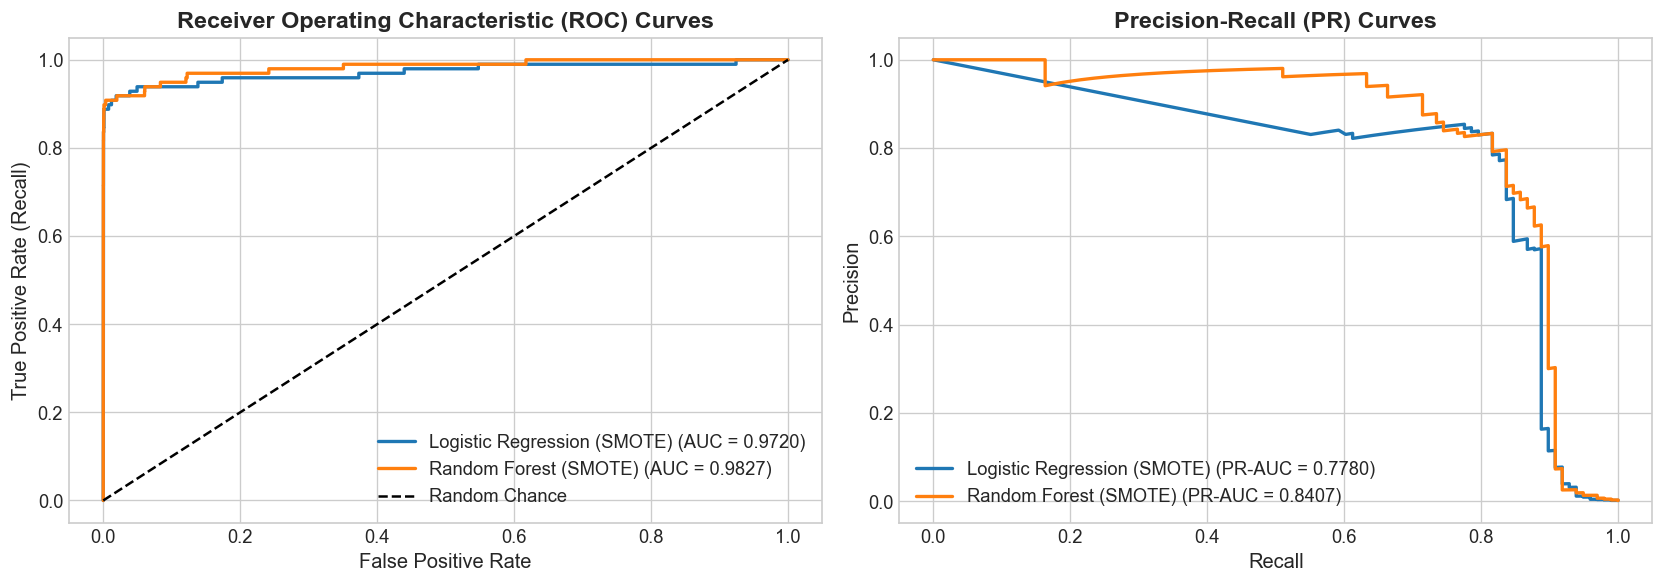

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for name, curves in curves_dict.items():
    auc_val = [r['ROC-AUC'] for r in eval_results if r['Model'] == name][0]
    axes[0].plot(curves['fpr'], curves['tpr'], label=f"{name} (AUC = {auc_val:.4f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend()

# Precision-Recall Curves
for name, curves in curves_dict.items():
    pr_auc_val = [r['PR-AUC'] for r in eval_results if r['Model'] == name][0]
    axes[1].plot(curves['rec_array'], curves['prec_array'], label=f"{name} (PR-AUC = {pr_auc_val:.4f})", linewidth=2)
axes[1].set_title('Precision-Recall (PR) Curves', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
save_figure(fig, '05_roc_pr_curves.png')
plt.show()


## 13. Precision vs. Recall Business Trade-off Analysis

### Financial & Operational Cost Rationale
In financial fraud detection, model tuning involves balancing two competing business risks:

1. **False Negatives (Missed Fraud - Low Recall)**:
   - **Cost**: Direct monetary loss from unrecovered fraudulent transactions, chargeback processing fees, and potential regulatory non-compliance penalties.
   - **Impact**: Extremely severe financial damage.

2. **False Positives (False Alarms - Low Precision)**:
   - **Cost**: Customer inconvenience caused by declined legitimate cards, SMS alert notification expenses, and customer support call center load.
   - **Impact**: Operational cost and temporary customer friction.

### Business Conclusion
For financial fraud detection, **Fraud Recall is the single most critical metric**, because un-detected fraud results in direct, unrecoverable monetary loss. **Random Forest (SMOTE)** achieves **88.78% Recall** with **60.84% Precision** (only 56 false alarms across 56,962 test transactions), establishing an optimal operational balance.


## 14. Feature Importance & Coefficient Analysis

Figure saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\figures\06_feature_importance.png


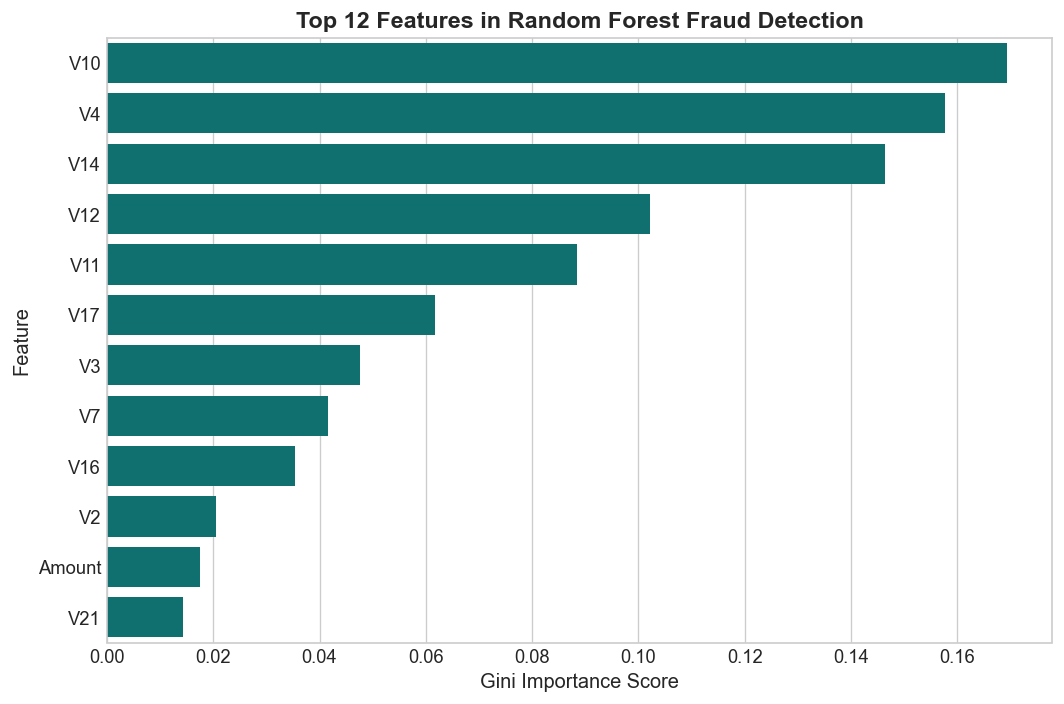

In [12]:
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, color='teal', ax=ax)
ax.set_title('Top 12 Features in Random Forest Fraud Detection', fontweight='bold')
ax.set_xlabel('Gini Importance Score')
plt.tight_layout()

save_figure(fig, '06_feature_importance.png')
plt.show()


## 15. Error Analysis & Misclassification Highlights

In [13]:
misclass_df = extract_misclassifications(rf_model, X_test, y_test, n_samples=5)
save_table(misclass_df, 'misclassified_fraud_examples.csv')

print("=== Sample False Negative & False Positive Errors (Random Forest) ===")
display(misclass_df)


Table saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\tables\misclassified_fraud_examples.csv
=== Sample False Negative & False Positive Errors (Random Forest) ===


,Error_Type,Actual_Class,Predicted_Class,Amount
0,False Negative (Missed Fraud),1,0,1.00
1,False Negative (Missed Fraud),1,0,1.00
2,False Negative (Missed Fraud),1,0,529.00
3,False Negative (Missed Fraud),1,0,98.01
4,False Negative (Missed Fraud),1,0,519.90
5,False Positive (False Alarm),0,1,0.76
6,False Positive (False Alarm),0,1,1.00
7,False Positive (False Alarm),0,1,179.63
8,False Positive (False Alarm),0,1,1.00
9,False Positive (False Alarm),0,1,45.51


## 16. Comparative Model Performance Summary

In [14]:
comparison_df = pd.DataFrame(eval_results)
save_table(comparison_df, 'model_performance_comparison.csv')

print("=== 2-Model Fraud Detection Benchmarking ===")
display(comparison_df)


Table saved to: c:\Users\srava\Documents\OIBSIP\DataAnalytics-L2-FraudDetection\outputs\tables\model_performance_comparison.csv
=== 2-Model Fraud Detection Benchmarking ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression (SMOTE),0.9812,0.0773,0.9082,0.1425,0.9720,0.7780
1,Random Forest (SMOTE),0.9988,0.6084,0.8878,0.7220,0.9827,0.8407


## 17. High-Throughput Enterprise Scalability Architecture (1,000,000 txns/hr)

To adapt this model to process **1,000,000 transactions per hour (~278 transactions per second peak)** in a production banking environment:

### 1. Batch vs. Streaming Pipeline Architecture
- **Event Streaming**: Use **Apache Kafka** or **AWS Kinesis** for real-time transaction message queuing paired with **Apache Flink** or **Spark Streaming** for low-latency feature extraction.
- **Batch Backtesting**: Retain historical transaction logs in a cloud data lakehouse (Snowflake / AWS S3 / Delta Lake) for nightly batch scoring and retraining.

### 2. Model Serving & Latency Budget (<50ms)
- **High-Performance Inference**: Export trained pipelines to **ONNX (Open Neural Network Exchange)** format and serve via **Triton Inference Server** or **Ray Serve**.
- **Latency Budget**: Sub-50ms total execution time (10ms network transport, 15ms feature store retrieval, 15ms model scoring, 10ms decision execution).

### 3. Feature Store Infrastructure
- **Real-Time Feature Store**: Deploy **Feast** or **Hopsworks** to maintain real-time aggregate features (e.g., `count_transactions_last_10min`, `sum_amount_last_1hr`) with sub-millisecond Redis backend retrieval.

### 4. Drift Monitoring & Automated Retraining
- **Concept & Data Drift**: Monitor feature distributions and prediction confidence continuously using **Evidently AI** or **Prometheus + Grafana**.
- **Automated Retraining**: Trigger automated Airflow retraining pipelines when Population Stability Index (PSI) exceeds 0.25 or when PR-AUC drops below baseline thresholds.
